In [1]:
import sys
sys.path.append("../")

import pandas as pd

from src.preprocessing import create_model_features
from src.modeling import (
    split_data,
    train_linear_regression,
    train_decision_tree,
    train_random_forest,
    evaluate_model,
    save_model,
    get_best_model,
    generate_future_forecast
)
from src.visualization import plot_predictions, plot_model_comparison, plot_future_forecast

In [2]:
monthly_sales = pd.read_csv("../data/processed/monthly_sales.csv")
monthly_sales["Date"] = pd.to_datetime(monthly_sales["Date"])
monthly_sales.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


## Feature Engineering

In [3]:
model_data = create_model_features(monthly_sales)
model_data.head()

,Date,Sales,year,month,quarter,month_sin,month_cos,lag_1,lag_2,lag_3,rolling_mean_3,rolling_mean_6
0,2015-07-31,33781.5430,2015,7,3,-0.500000,-8.660254e-01,34322.9356,23644.3030,27906.8550,28624.697867,26634.248267
1,2015-08-31,27117.5365,2015,8,3,-0.866025,-5.000000e-01,33781.5430,34322.9356,23644.3030,30582.927200,29896.887600
2,2015-09-30,81623.5268,2015,9,3,-1.000000,-1.836970e-16,27117.5365,33781.5430,34322.9356,31740.671700,33663.161683
3,2015-10-31,31453.3930,2015,10,4,-0.866025,5.000000e-01,81623.5268,27117.5365,33781.5430,47507.535433,38066.116650
4,2015-11-30,77907.6607,2015,11,4,-0.500000,8.660254e-01,31453.3930,81623.5268,27117.5365,46731.485433,38657.206317


In [4]:
model_data.to_csv("../data/processed/model_data.csv", index=False)

## Chia train/test theo thời gian

In [5]:
X_train, X_test, y_train, y_test, date_test = split_data(model_data)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (33, 10)
X_test: (9, 10)
y_train: (33,)
y_test: (9,)


## Train 3 mô hình

In [6]:
lr_model = train_linear_regression(X_train, y_train)
dt_model = train_decision_tree(X_train, y_train)
rf_model = train_random_forest(X_train, y_train)

models = {
    "Linear Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

## Đánh giá mô hình

In [7]:
rows = []
predictions_dict = {}

for model_name, model in models.items():
    pred, mae, rmse, mape, r2 = evaluate_model(model, X_test, y_test)
    predictions_dict[model_name] = pred
    rows.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    })

comparison = pd.DataFrame(rows)
comparison.sort_values("RMSE")

,Model,MAE,RMSE,MAPE,R2
0,Linear Regression,12788.973776,15594.246380,18.923329,0.617106
2,Random Forest,13428.456108,17696.443972,18.369839,0.506915
1,Decision Tree,19633.721544,24273.188106,27.979152,0.072309


In [8]:
comparison.to_csv("../reports/tables/model_comparison.csv", index=False)

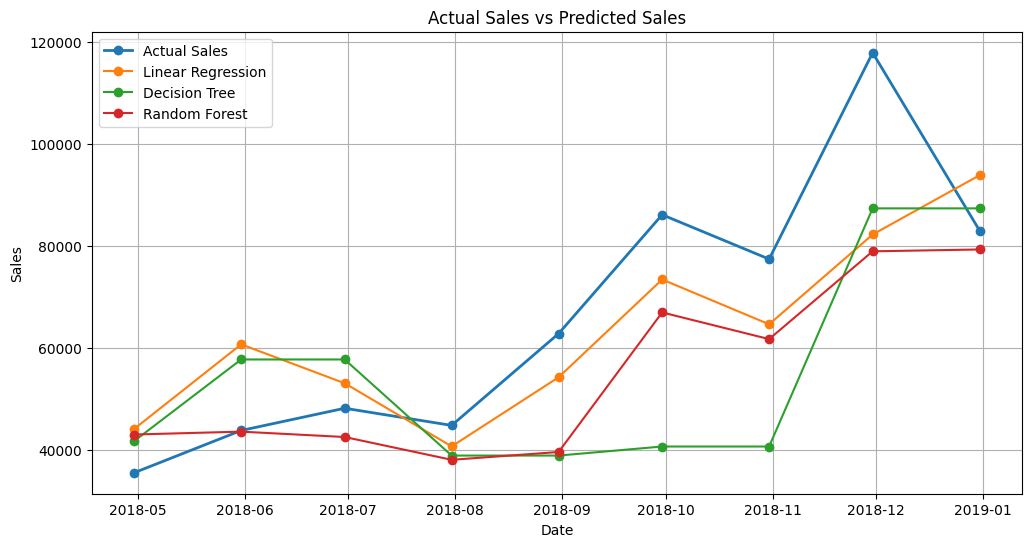

In [9]:
plot_predictions(date_test, y_test, predictions_dict, "../reports/figures/prediction_comparison.png")

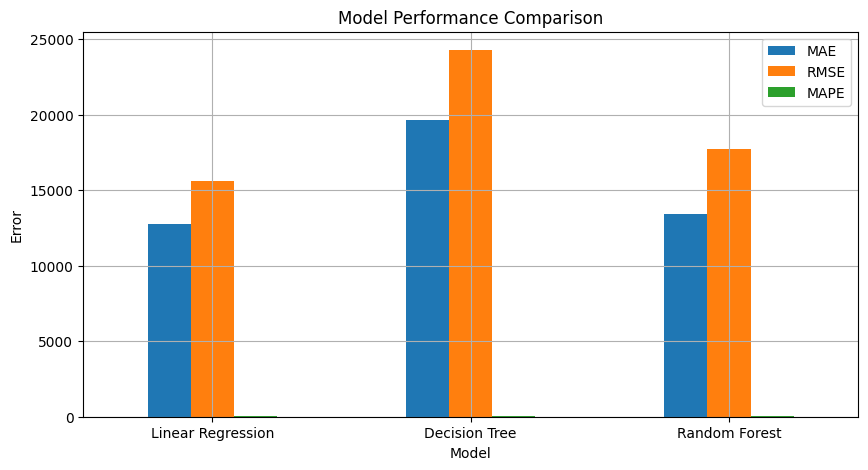

In [10]:
plot_model_comparison(comparison, "../reports/figures/model_comparison.png")

## Lưu mô hình

In [11]:
save_model(lr_model, "../models/linear_regression_model.pkl")
save_model(dt_model, "../models/decision_tree_model.pkl")
save_model(rf_model, "../models/random_forest_model.pkl")

## Chọn mô hình tốt nhất và dự báo 12 tháng tiếp theo

In [12]:
best_model_name, best_model = get_best_model(comparison, models, metric="RMSE")
print("Best model by RMSE:", best_model_name)

Best model by RMSE: Linear Regression


In [13]:
future_df = generate_future_forecast(model_data, best_model, periods=12)
future_df[["Date", "Sales"]]

,Date,Sales
0,2019-01-31,33515.636122
1,2019-02-28,42177.807075
2,2019-03-28,66150.392047
3,2019-04-28,59361.164443
4,2019-05-28,62645.466494
5,2019-06-28,57604.591318
6,2019-07-28,44049.107602
7,2019-08-28,63482.132812
8,2019-09-28,84077.049610
9,2019-10-28,78341.097721


In [14]:
future_df[["Date", "Sales"]].to_csv("../reports/tables/future_forecast.csv", index=False)

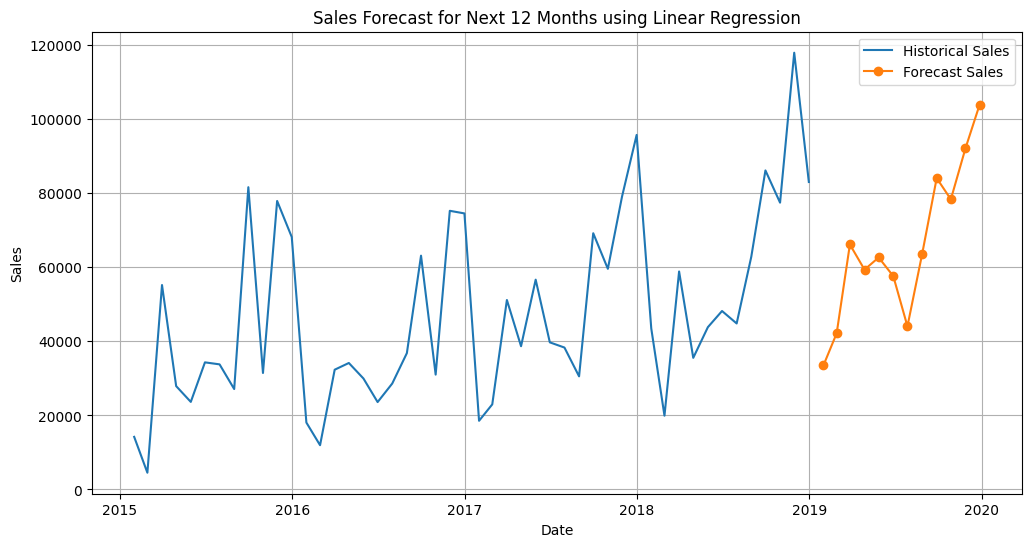

In [15]:
plot_future_forecast(monthly_sales, future_df, best_model_name, "../reports/figures/future_forecast.png")